# Autoencoder-based Financial Fraud Detection (Colab)

**What this notebook does:**

- Load your `cleaned_bank_transactions.csv` (upload to Colab)
- Preprocess (drop ID cols, one-hot encode categoricals, scale features)
- Build and train a dense Autoencoder (unsupervised anomaly detection)
- Evaluate using reconstruction error and (optionally) available `Class` labels
- Produce EDA charts and interactive Plotly figures
- Launch a Streamlit dashboard from Colab (requires ngrok authtoken)

---


In [1]:
# Install required packages
!pip install -q numpy pandas scikit-learn matplotlib seaborn tensorflow plotly joblib streamlit pyngrok colabcode

# Some packages may print installation logs — that's normal.
print('Installed packages (if not already present).')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.1 MB/s eta 0:00:00
Requested uvicorn==0.13.1 from https://files.pythonhosted.org/packages/ef/67/546c35e9fffb585ea0608ba3bdcafe17ae402e304367203d0b08d6c23051/uvicorn-0.13.1-py3-none-any.whl (from colabcode) has invalid metadata: .* suffix can only be used with `==` or `!=` operators
    python-dotenv (>=0.13.*) ; extra == 'standard'
                   ~~~~~~~^
Please use pip<24.1 if you need to use this version.
Requested uvicorn==0.13.1 from https://files.pythonhosted.org/packages/ef/67/546c35e9fffb585ea0608ba3bdcafe17ae402e304367203d0b08d6c23051/uvicorn-0.13.1-py3-none-any.whl (from colabcode) has invalid metadata: .* suffix can only be used with `==` or `!=` operators
    python-dotenv (>=0.13.*) ; extra == 'standard'
                   ~~~~~~~^
Please use pip<24.1 if you need to use this version.
Requested uvicorn==0.13.1 from https://files.pythonhosted.org/packages/ef/67/546c35e9fffb585ea0608ba3bdcafe17ae402e304367203d0b0

In [2]:
# Upload your dataset: cleaned_bank_transactions.csv
from google.colab import files
uploaded = files.upload()  # choose cleaned_bank_transactions.csv from your machine

# Confirm file present
import os
for name in uploaded.keys():
    print('Uploaded:', name)
if 'cleaned_bank_transactions.csv' not in uploaded and len(uploaded)==1:
    # if user uploaded with different name, rename it for consistency
    fn = list(uploaded.keys())[0]
    os.rename(fn, 'cleaned_bank_transactions.csv')
    print('Renamed uploaded file to cleaned_bank_transactions.csv')

Saving cleaned_bank_transactions.csv to cleaned_bank_transactions.csv
Uploaded: cleaned_bank_transactions.csv


In [3]:
import pandas as pd
df = pd.read_csv('cleaned_bank_transactions.csv')
print('Dataset shape:', df.shape)
display(df.head())

# Show columns and types
print('\nColumn types:')
print(df.dtypes)

Dataset shape: (2512, 16)


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IPAddress,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX001063,AC00456,68.10,2023-01-02 16:00:06,Debit,Milwaukee,D000235,94.227.164.192,M089,ATM,20,Student,47,1,1382.80,2024-11-04 08:10:15
1,TX001369,AC00316,487.16,2023-01-02 16:01:14,Credit,Los Angeles,D000361,156.96.135.18,M077,Branch,28,Student,84,1,321.21,2024-11-04 08:12:22
2,TX001623,AC00087,154.21,2023-01-02 16:01:26,Debit,Miami,D000549,190.251.45.32,M083,Online,46,Engineer,75,1,8045.77,2024-11-04 08:10:33
3,TX000983,AC00281,453.49,2023-01-02 16:06:29,Debit,Seattle,D000471,40.226.196.34,M088,Branch,66,Doctor,147,1,6366.43,2024-11-04 08:08:56
4,TX000877,AC00304,204.06,2023-01-02 16:07:17,Debit,Washington,D000685,150.231.20.169,M069,Online,77,Retired,159,1,4351.83,2024-11-04 08:07:22



Column types:
TransactionID               object
AccountID                   object
TransactionAmount          float64
TransactionDate             object
TransactionType             object
Location                    object
DeviceID                    object
IPAddress                   object
MerchantID                  object
Channel                     object
CustomerAge                  int64
CustomerOccupation          object
TransactionDuration          int64
LoginAttempts                int64
AccountBalance             float64
PreviousTransactionDate     object
dtype: object


In [4]:
# Preprocessing function: drops ID-like columns, encodes categorical, scales numeric
import numpy as np
from sklearn.preprocessing import StandardScaler

def preprocess(df, label_col='Class', drop_id_like=True, scale=True):
    df = df.copy()
    # Save labels if present
    y = None
    if label_col in df.columns:
        y = df[label_col].astype(int).values
        df = df.drop(columns=[label_col])
    # Drop obvious ID-like columns
    if drop_id_like:
        id_cols = [c for c in df.columns if 'id' in c.lower() or 'txn' in c.lower() or 'transaction' in c.lower()]
        df = df.drop(columns=id_cols, errors='ignore')
    # Separate dtypes
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    # One-hot encode categoricals
    if len(cat_cols) > 0:
        df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    feature_cols = df.columns.tolist()
    X = df.values.astype(float)
    scaler = None
    if scale:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)
    return X, y, feature_cols, scaler

X, y, features, scaler = preprocess(df)
print('Processed shape:', X.shape)
print('Number of features:', len(features))

Processed shape: (2512, 641)
Number of features: 641


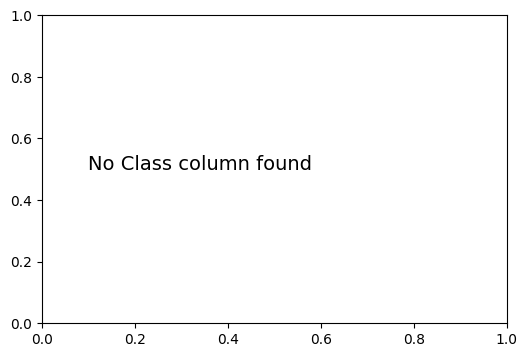

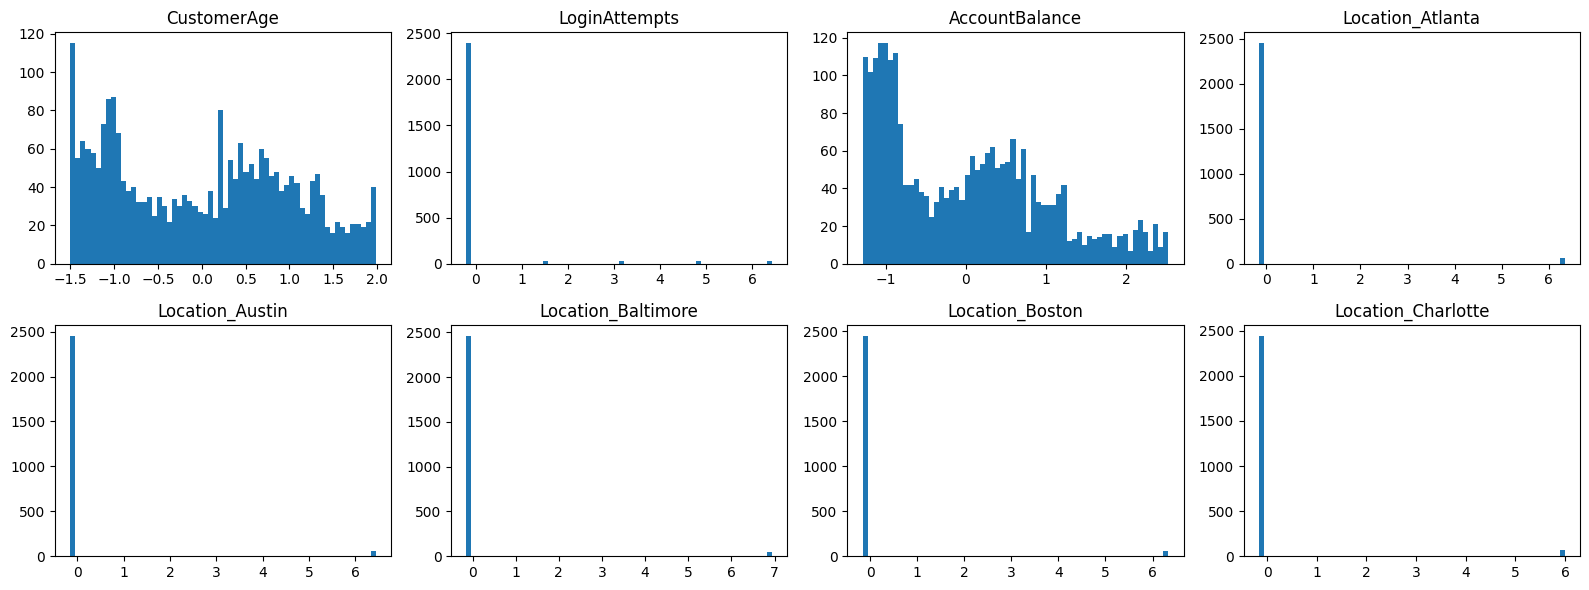

In [5]:
# Basic EDA: class balance (if available), feature histograms for top numeric cols
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(6,4))
if 'Class' in pd.read_csv('cleaned_bank_transactions.csv').columns:
    tmp = pd.read_csv('cleaned_bank_transactions.csv')['Class'].value_counts()
    sns.barplot(x=tmp.index, y=tmp.values)
    plt.title('Class distribution (0=legit,1=fraud)')
    plt.xlabel('Class')
    plt.ylabel('Count')
else:
    plt.text(0.1, 0.5, 'No Class column found', fontsize=14)
plt.show()

# Plot histograms for first 8 features
nplot = min(8, X.shape[1])
fig, axs = plt.subplots(2,4, figsize=(16,6))
axs = axs.flatten()
for i in range(nplot):
    axs[i].hist(X[:,i], bins=60)
    axs[i].set_title(features[i])
plt.tight_layout()
plt.show()

In [6]:
# Build a dense autoencoder model (Keras)
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses

def build_autoencoder(input_dim, encoding_dim=16, hidden_dims=[64,32]):
    inp = layers.Input(shape=(input_dim,))
    x = inp
    for h in hidden_dims:
        x = layers.Dense(h, activation='relu')(x)
    latent = layers.Dense(encoding_dim, activation='relu', name='latent')(x)
    x = latent
    for h in reversed(hidden_dims):
        x = layers.Dense(h, activation='relu')(x)
    out = layers.Dense(input_dim, activation='linear')(x)
    ae = models.Model(inputs=inp, outputs=out, name='autoencoder')
    ae.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss=losses.MeanSquaredError())
    return ae

input_dim = X.shape[1]
ae = build_autoencoder(input_dim, encoding_dim=16, hidden_dims=[128,64,32])
ae.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 641)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 641)            │        82,689 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186,705 (729.32 KB)

 Trainable params: 186,705 (729.32 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train the autoencoder using only normal transactions if labels exist
from sklearn.model_selection import train_test_split
import joblib

if y is not None:
    X_normal = X[y==0]
else:
    X_normal = X

X_train, X_val = train_test_split(X_normal, test_size=0.2, random_state=42)
print('Train shape:', X_train.shape, 'Val shape:', X_val.shape)

history = ae.fit(X_train, X_train,
                 epochs=50,
                 batch_size=2048,
                 validation_data=(X_val, X_val),
                 callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)],
                 verbose=2)

# Save model (use native Keras format to avoid old HDF5 issues)
MODEL_DIR = 'models'
import os
os.makedirs(MODEL_DIR, exist_ok=True)
model_path = os.path.join(MODEL_DIR, 'autoencoder.keras')
ae.save(model_path)
# Save scaler & features
joblib.dump({'scaler': scaler, 'features': features}, os.path.join(MODEL_DIR, 'preproc.joblib'))
print('Saved model to', model_path)

Train shape: (2009, 641) Val shape: (503, 641)
Epoch 1/50
1/1 - 3s - 3s/step - loss: 1.0049 - val_loss: 0.9850
Epoch 2/50
1/1 - 0s - 279ms/step - loss: 1.0041 - val_loss: 0.9847
Epoch 3/50
1/1 - 0s - 140ms/step - loss: 1.0036 - val_loss: 0.9845
Epoch 4/50
1/1 - 0s - 137ms/step - loss: 1.0033 - val_loss: 0.9844
Epoch 5/50
1/1 - 0s - 138ms/step - loss: 1.0031 - val_loss: 0.9843
Epoch 6/50
1/1 - 0s - 139ms/step - loss: 1.0029 - val_loss: 0.9843
Epoch 7/50
1/1 - 0s - 155ms/step - loss: 1.0026 - val_loss: 0.9842
Epoch 8/50
1/1 - 0s - 285ms/step - loss: 1.0024 - val_loss: 0.9841
Epoch 9/50
1/1 - 0s - 399ms/step - loss: 1.0021 - val_loss: 0.9840
Epoch 10/50
1/1 - 0s - 294ms/step - loss: 1.0017 - val_loss: 0.9838
Epoch 11/50
1/1 - 0s - 237ms/step - loss: 1.0014 - val_loss: 0.9837
Epoch 12/50
1/1 - 0s - 284ms/step - loss: 1.0009 - val_loss: 0.9836
Epoch 13/50
1/1 - 0s - 294ms/step - loss: 1.0005 - val_loss: 0.9834
Epoch 14/50
1/1 - 0s - 352ms/step - loss: 1.0000 - val_loss: 0.9832
Epoch 15/50
1

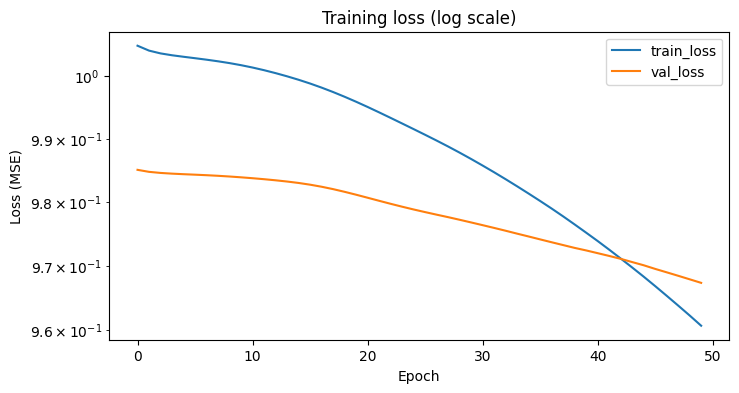

In [8]:
# Plot loss curve
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('Training loss (log scale)')
plt.show()

In [9]:
# Compute reconstruction errors on full dataset and choose threshold
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix

# Load saved model with explicit loss/cust objs to avoid MSE string issues
from tensorflow.keras.models import load_model
saved_ae = load_model(model_path, compile=False)

# Reconstruct and compute MSE per sample
X_all = X
recon = saved_ae.predict(X_all)
mse = np.mean(np.power(X_all - recon, 2), axis=1)

# Choose threshold (99th percentile of training errors)
train_errors = np.mean(np.power(X_train - saved_ae.predict(X_train), 2), axis=1)
threshold = np.percentile(train_errors, 99)
print('Threshold (99th percentile):', threshold)

# If labels exist, evaluate
if y is not None:
    y_pred = (mse >= threshold).astype(int)
    print('AUC (errors):', roc_auc_score(y, mse))
    print('Precision:', precision_score(y, y_pred, zero_division=0))
    print('Recall:', recall_score(y, y_pred, zero_division=0))
    print('F1:', f1_score(y, y_pred, zero_division=0))
    print('Confusion matrix:\n', confusion_matrix(y, y_pred))

# Attach mse & anomaly flag to dataframe for plotting
df_results = pd.read_csv('cleaned_bank_transactions.csv').copy()
df_results['reconstruction_error'] = mse
df_results['anomaly'] = (df_results['reconstruction_error'] >= threshold).astype(int)
print('Detected anomalies:', int(df_results['anomaly'].sum()), 'out of', len(df_results))

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Threshold (99th percentile): 3.758819624673715
Detected anomalies: 27 out of 2512


In [10]:
import plotly.express as px
fig = px.histogram(df_results, x='reconstruction_error', nbins=200, title='Reconstruction error distribution')
fig.show()

In [11]:
# Show top anomalies
display(df_results.sort_values('reconstruction_error', ascending=False).head(20))

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IPAddress,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,reconstruction_error,anomaly
1193,TX001580,AC00028,398.36,2023-06-27 16:52:00,Debit,Columbus,D000022,80.58.55.129,M006,ATM,22,Student,56,1,1863.70,2024-11-04 08:09:08,4.064838,1
772,TX002508,AC00297,856.21,2023-04-26 17:09:36,Credit,Colorado Springs,D000625,21.157.41.17,M072,Branch,33,Doctor,109,1,12690.79,2024-11-04 08:11:29,4.051375,1
2251,TX002119,AC00248,746.78,2023-11-27 16:29:16,Credit,Mesa,D000243,112.66.191.48,M001,Branch,21,Student,64,1,1699.81,2024-11-04 08:07:44,4.040352,1
457,TX002283,AC00191,372.08,2023-03-06 16:37:23,Debit,Houston,D000470,102.203.223.1,M032,Branch,66,Doctor,63,1,13330.74,2024-11-04 08:12:15,4.029859,1
2155,TX000441,AC00040,1237.56,2023-11-13 17:49:04,Credit,Austin,D000077,219.96.187.255,M060,Branch,60,Engineer,159,1,9410.17,2024-11-04 08:11:45,4.013382,1
1754,TX000192,AC00099,226.37,2023-09-18 17:07:08,Credit,Louisville,D000631,206.62.122.93,M041,Branch,49,Doctor,141,1,9840.04,2024-11-04 08:09:56,3.998682,1
2167,TX002211,AC00349,23.14,2023-11-15 17:23:40,Credit,Mesa,D000555,122.30.82.244,M064,Online,47,Doctor,93,1,10536.54,2024-11-04 08:09:21,3.926001,1
1069,TX002000,AC00261,27.64,2023-06-09 17:14:26,Debit,New York,D000044,208.142.57.37,M065,Online,54,Engineer,23,1,7498.51,2024-11-04 08:08:22,3.922105,1
2483,TX001702,AC00411,111.55,2023-12-28 16:27:12,Debit,Denver,D000632,81.156.221.124,M039,ATM,46,Doctor,101,1,12221.17,2024-11-04 08:08:09,3.917298,1
1742,TX000340,AC00299,23.71,2023-09-18 16:04:52,Debit,Atlanta,D000284,2.61.10.58,M005,Branch,58,Doctor,164,1,10788.89,2024-11-04 08:09:16,3.891855,1
